In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import cftime as cftime
import xarray as xr
import rasterio as rio
import rioxarray as rxr
from shapely.geometry import mapping
import geopandas as gpd

### Data preparation

In [10]:
# This part of the code allows to load the input data and set the spatio-tmeporal weight

def load_dataset(hazard_name,variable_name):
  # This function takes the input climate data for each hazard in the format of netcdf files. 
  # Two type of files are required: the netcdf of values above thresholds and the original climate variable
  # It loads the input data into a dataset with xarray and merges the daily climate data with the masks into a single dataset

  # Input variables:
  # model: corresponds to the name of the climate model or the reanalysis; it is used as part of the name of the file path
  # percentile: corresponds to the percentile applied in the threshold calculation; it is used as part of the name of the file path
  # variable: name of the climate variable; it is used as part of the name of the file path
  # mask name: name of the file mask (events above threshold); it is used as part of the name of the file path
  # values name: name of the file of the daily climate variable; it is used as part of the name of the file path
  # var name: name of the climate variable; it is used to access the variable in the xarray dataset
  # start_year: first year of the data; it is used as part of the name of the file path

  # Output variable:
  # an xarray dataset with updated names for the climate variable and the mask
  path_name='INPUT_data/'+hazard_name+'_mask.nc'
  path_values='INPUT_data/'+hazard_name+'_data.nc'
  var_mask=xr.open_dataset(str(path_name))
  var_values=xr.open_dataset(str(path_values))
  var_all=var_values.merge(var_mask)
  error_code='Full_dataset'
  return(var_all)


def day_sequence(var_df,start_date):
  #This functions creates a list of days from 1 to the end of the time period, useful to calculate distance in the time dimension
  # Slice the data to select only a timeframe, provide the start year (e.g., January 1, 2023)
  start_date = start_date.date()
  #print('the reference date is',start_date)
  list_of_days=[]
  for i in var_df.time:
    #print('the day counted is',i)
    time_difference = i - start_date
    #print('the time_difference is',time_difference)
    days_elapsed = time_difference.days
    #print('the days elapsed are',days_elapsed)
    days_elapsed_integer = int(days_elapsed)
    list_of_days.append(days_elapsed_integer)
  return(list_of_days)
  #print('the final integer is',days_elapsed_integer)

#This functions creates the days sequence with the progressive list of days produced in the day_sequence function
def time_preprocessing(var_ds,year_start='2018',year_end='2022'):#add a column with a progressive list of days
  var_ds=var_ds.sel(time=slice(str(year_start),str(year_end)))
  var_df=var_ds.to_dataframe().dropna().reset_index()
  var_df['time']=pd.to_datetime(var_df['time']).dt.date
  day_1=pd.to_datetime(str(year_start)+'-1-1')
  days_list=day_sequence(var_df,day_1)
  var_df['days']=days_list
  return(var_df)

#This function numbers cells in a progressive way, in order to have a unique reference ID for each cell
def cell_preprocessing(var_df):#add a column with a progressive list of cells and return also the df with the pairing
  var_df['cell'] = var_df.groupby(['lon', 'lat']).ngroup() + 1
  df_mapping=var_df[['cell','lon','lat']].drop_duplicates(subset='cell')
  return var_df,df_mapping
# to recrete the orginal coordinates: merged_df = prova.merge(wind_coords, on='cell', how='left')

#This function filters the mask file with minimum empirical thresholds. E.g., 20 mm/day fo precipitation, 13.9 m/s for wind
def filtering_thresholds(var_df,var_name,option):
  if option=='_NO_F_':
      return(var_df)
  #print(var_name)
  if 'WIND_SPEED' in var_name:
    threshold=13.9 #more than Gale force 7
    var_df[var_name]= var_df.apply(lambda row: 0 if row['WIND_SPEED'] < threshold else row[var_name], axis=1)
  if 'TOT_PREC' in var_name:
    threshold=20
    var_df[var_name]= var_df.apply(lambda row: 0 if row['TOT_PREC'] < threshold else row[var_name], axis=1)
  if 'T_2M' in var_name:
    threshold=273.15 # more than 0 ºC
    var_df[var_name]= var_df.apply(lambda row: 0 if row['T_2M'] < threshold else row[var_name], axis=1)
  return(var_df)

#This function sets the distance between two cells in x and y dimension to 1 for the CMCC dataset
def spatio_temporal_weight(cluster_df,lon_factor=35.335689,lat_factor=50.3778338): #these factors are specific for the dimension in degree of the remapped dataset
  cluster_df['new_lon']=cluster_df['lon']*lon_factor
  cluster_df['new_lat']=cluster_df['lat']*lat_factor
  min_lat=cluster_df['new_lat'].min()
  min_lon=cluster_df['new_lon'].min()
  cluster_df['new_lon']=cluster_df['new_lon']-min_lon
  cluster_df['new_lat']=cluster_df['new_lat']-min_lat
  return(cluster_df)

### Clustering single hazards

In [13]:
#This is the code for the DBSCAN clustering, and takes as input: 


def single_hazard_clusters_update(df_single_cluster):
  # This function calculates the characteristics of the clusters and applies a spatial merge
  # Without the spatial merge, each day can have different clusters
  # given the extremely local application in Veneto, different clusters are merged together if they happen on the same day
  # in case of wider areas of application, this has to be removed to investigate spatially co-occurring hazards   
  df_char_temp=cluster_characteristics(df_single_cluster,'clusters')#calculates start day, end day, duration, extension of the original clusters
  df_char_temp=df_char_temp[df_char_temp['clusters']!=-1]
  df_preproc=merging_clusters(df_char_temp,0) #merging cluster function. delta=0 implies only a spatial merge
  df_single_cluster=df_single_cluster[df_single_cluster['clusters']!=-1]
  df_new_char=clustering_new_indexing(df_char_temp,df_preproc)#reindex clusters atfer merging
  df_merging=df_new_char[['clusters','new_clusters']]
  df_final_single_cluster=df_single_cluster.merge(df_merging,on='clusters')
  df_final_chars=cluster_characteristics(df_final_single_cluster,'new_clusters')#calculates new hazard characteristics after merge
  return(df_final_single_cluster,df_final_chars)

#Calculating the characteristics fo the clusters, to check for duration, intensity and fragmentation of the analysis. 
# Used later to merge events happening in the same day

def cluster_characteristics(df_cluster,cluster_col):
    df_cluster['time'] = pd.to_datetime(df_cluster['time'])
    # Get min and max time per cluster
    day_min = df_cluster.groupby(cluster_col)['time'].min().rename('day_start')
    day_max = df_cluster.groupby(cluster_col)['time'].max().rename('day_end')
    # Compute daily cell counts
    extension = df_cluster.groupby([cluster_col, 'time'])['lat'].count().rename('cells_per_day').reset_index() 
    # Aggregating cell count statistics
    extension_stats = extension.groupby(cluster_col)['cells_per_day'].agg(
        extension_mean='mean',
        extension_min='min',
        extension_max='max'
    )
    # Total elements per cluster
    total_cluster = df_cluster.groupby(cluster_col)['lat'].count().rename('total_elements')
    # Merging all statistics
    cluster_chars = (
        pd.concat([day_min, day_max, extension_stats, total_cluster], axis=1)
        .reset_index()
    )
    # Compute duration in days
    cluster_chars['duration'] = ((cluster_chars['day_end'] - cluster_chars['day_start']).dt.total_seconds() + 86400) / (24 * 60 * 60)
    # Compute date difference between consecutive clusters
    cluster_chars['date_difference'] = cluster_chars['day_start'].shift(-1) - cluster_chars['day_end']

    return cluster_chars

def merging_clusters(df,delta):
    #delta is the number of days in which i want to merge clusters. 
    #If delta is set to 0, the function merges clusters only spatially.
    merged_clusters = pd.DataFrame(columns=['clusters', 'day_start', 'day_end', 'new_order'])# Create an empty DataFrame to store the results
    new_order_counter = 1 # Initialize the new_order counter
    dfs = []# List to collect DataFrames for concatenation

    # Iterate through each row in the original DataFrame
    for index, row in df.iterrows():
        # Check if the current row overlaps with any existing merged clusters
        overlapping_clusters = merged_clusters[
            (merged_clusters['day_start'] <= row['day_end'] + pd.Timedelta(days=delta)) & 
            (merged_clusters['day_end'] >= row['day_start'] + pd.Timedelta(days=-delta))
        ]
        if overlapping_clusters.empty:
            # If no overlapping clusters, create a new merged cluster
            new_row = pd.DataFrame([{
                'clusters': row['clusters'],
                'day_start': row['day_start'],
                'day_end': row['day_end'],
                'new_order': new_order_counter
            }])
            dfs.append(new_row)
            new_order_counter += 1
        else:
            # If overlapping clusters, merge them and update the new_order for all involved clusters
            merged_clusters = merged_clusters[~merged_clusters['clusters'].isin(overlapping_clusters['clusters'])]
            new_row = pd.DataFrame([{
                'clusters': ', '.join(map(str, overlapping_clusters['clusters'].tolist() + [row['clusters']])),
                'day_start': min(overlapping_clusters['day_start'].min(), row['day_start']),
                'day_end': max(overlapping_clusters['day_end'].max(), row['day_end']),
                'new_order': new_order_counter
            }])
            dfs.append(new_row)
            new_order_counter += 1

        # Update merged_clusters DataFrame after processing each row
        if dfs:
            merged_clusters = pd.concat([merged_clusters] + dfs, ignore_index=True)
            dfs.clear()

    return merged_clusters

def clustering_new_indexing(df_char,df_processed):
  df_processed['new_cluster_label']=df_processed.index
  list_of_vals=[]
  for index,row in df_processed.iterrows():
    if type(row['clusters']) != int:
      cluster_values = row['clusters'].split(', ')
    else:
      cluster_values=[int(row['clusters'])]
    length=len(cluster_values)
    for i in range(0,length):
      list_of_vals.append(row['new_cluster_label'])
  df_char['new_clusters']=list_of_vals
  return(df_char)


def single_hazard_cluster(hazard,variable,weight,epsilon,minimum_points,option):
  var_ds=load_dataset(hazard,variable)
  var_ds2=time_preprocessing(var_ds)
  var_ds2,var_coords=cell_preprocessing(var_ds2)
  result_df,grid_df,params_df,noise_df=clustering_application(var_ds2,variable,weight,epsilon,minimum_points,option)
  new_result,grid_df2=single_hazard_clusters_update(result_df)
  new_result.drop(columns='clusters',inplace=True)
  return(new_result,grid_df2,params_df,noise_df)

## Testing the clustering process with old parameters

In [7]:
heatwave,grid_heatwave=single_hazard_cluster('temp','T_2M',1,5,20,'_YES_F_')

/var/folders/yx/tl4bksqx70gc81vxn7h5jtl40000gn/T/ipykernel_20476/1859189735.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df['days'] = (cluster_df['days'] + 1) * day_weight
/var/folders/yx/tl4bksqx70gc81vxn7h5jtl40000gn/T/ipykernel_20476/1859189735.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crop_df['clusters'] = labels
/var/folders/yx/tl4bksqx70gc81vxn7h5jtl40000gn/T/ipykernel_20476/1859189735.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [8]:
precipitation,grid_precipitation=single_hazard_cluster('prec','TOT_PREC',10,11,100,'_YES_F_')

/var/folders/yx/tl4bksqx70gc81vxn7h5jtl40000gn/T/ipykernel_20476/1859189735.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df['days'] = (cluster_df['days'] + 1) * day_weight
/var/folders/yx/tl4bksqx70gc81vxn7h5jtl40000gn/T/ipykernel_20476/1859189735.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crop_df['clusters'] = labels
/var/folders/yx/tl4bksqx70gc81vxn7h5jtl40000gn/T/ipykernel_20476/1859189735.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [9]:
drought,grid_drought=single_hazard_cluster('drought','SPI_12',0.3,5,500,'_YES_F_')

/var/folders/yx/tl4bksqx70gc81vxn7h5jtl40000gn/T/ipykernel_20476/1859189735.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df['days'] = (cluster_df['days'] + 1) * day_weight
/var/folders/yx/tl4bksqx70gc81vxn7h5jtl40000gn/T/ipykernel_20476/1859189735.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crop_df['clusters'] = labels
/var/folders/yx/tl4bksqx70gc81vxn7h5jtl40000gn/T/ipykernel_20476/1859189735.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

In [10]:
wind,grid_wind=single_hazard_cluster('wind','WIND_SPEED',10,11,100,'_YES_F_')

/var/folders/yx/tl4bksqx70gc81vxn7h5jtl40000gn/T/ipykernel_20476/1859189735.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df['days'] = (cluster_df['days'] + 1) * day_weight
/var/folders/yx/tl4bksqx70gc81vxn7h5jtl40000gn/T/ipykernel_20476/1859189735.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  crop_df['clusters'] = labels
/var/folders/yx/tl4bksqx70gc81vxn7h5jtl40000gn/T/ipykernel_20476/1859189735.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

# Calibration of DBSCAN

In [1]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

def compute_k_distance(X, k):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)
    k_dist = np.sort(distances[:, -1])
    return k_dist

In [14]:
def clustering_application(var_df, var_name, day_weight, epsilon, min_elements, option):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.cluster import DBSCAN

    var_name_thres = var_name + '_MASK'

    # Filter the DataFrame
    var_df = filtering_thresholds(var_df, var_name_thres, option)
    grid_df = var_df.groupby(['lon','lat'])[var_name_thres].max().reset_index()
    grid_df.drop(columns=[var_name_thres], inplace=True)

    # Select only hazard = 1 points
    cluster_df = var_df[var_df[var_name_thres] == 1].copy()
    crop_df = cluster_df.copy()

    # Apply weights
    cluster_df['days'] = (cluster_df['days'] + 1) * day_weight
    cluster_df = cluster_df[['lat', 'lon', 'days']]
    cluster_df = spatio_temporal_weight(cluster_df)
    cluster_df = cluster_df[['new_lat', 'new_lon', 'days']]
    X = cluster_df.to_numpy()

    # -------------------------
    # DBSCAN CALIBRATION 
    # -------------------------

    # 1. Compute k-distance elbow
    m = int(min_elements)
    print("Calibrating using min_samples =", m)

    k_distances = compute_k_distance(X, k=m)
    eps_star = np.percentile(k_distances, 95)
    print("the radius I found is",eps_star)
    print("the m I found is",m)

    # Elbow visualization
    plt.figure(figsize=(7,4))
    plt.plot(k_distances, linewidth=2)
    plt.axhline(eps_star, color='red', linestyle='--')
    plt.title(f'k-distance Graph (k={m})')
    plt.xlabel('Points (sorted)')
    plt.ylabel(f'Distance to {m}-th neighbour')
    plt.grid(alpha=0.3)
    plt.show()

    # 2. Parameter ranges
    eps_values=[3, 4, 5, eps_star, 8] #set parameters
    #eps_values = [0.5 * eps_star, 0.7 * eps_star, 0.8 * eps_star, 0.9 * eps_star, eps_star, 1.1 * eps_star, 1.2 * eps_star, 1.3 * eps_star, 1.5 * eps_star, 2 * eps_star] #parameters around the eps star
    #min_samples_values = [int(x) for x in [m-200, m-100, m-50, m-20, m-10, m-5, m, m+5, m+10, m+20]]
    min_samples_values=[int(m-300),int(m-100), int(m), int(m+100), int(m+300)]

    # 3. Sweep using DBI ONLY
    param_df = dbscan_sweep_dbionly(X, eps_values, min_samples_values)

    # 4. Select best eps and min_samples
    eps_final, min_samples_final = select_best_dbscan_dbionly(param_df)

    # -------------------------
    # FINAL DBSCAN RUN
    # -------------------------
    dbscan_cluster_model = DBSCAN(eps=eps_final, min_samples=int(min_samples_final)).fit(X)
    labels = dbscan_cluster_model.labels_

    # Identify core samples
    core_samples_mask = np.zeros_like(labels, dtype=bool)
    core_samples_mask[dbscan_cluster_model.core_sample_indices_] = True

    # Assign labels back to dataframe
    crop_df['clusters'] = labels
    crop_df['core'] = core_samples_mask

    # -------------------------
    # FINAL NOISE CALCULATION
    # -------------------------
    final_noise_pct = float(np.mean(labels == -1))
    print(f"\nFinal noise percentage = {final_noise_pct:.3f}\n")

    return crop_df, grid_df, param_df, final_noise_pct

In [3]:
def dbscan_sweep_dbionly(X, eps_values, min_samples_values):
    from sklearn.cluster import DBSCAN
    from sklearn.metrics import davies_bouldin_score
    import numpy as np
    import pandas as pd

    records = []

    for eps in eps_values:
        eps = float(eps)

        for m in min_samples_values:
            m = int(m)

            model = DBSCAN(eps=eps, min_samples=m).fit(X)
            labels = model.labels_

            # DBSCAN failed to produce clusters
            if len(set(labels)) <= 1 or set(labels) == {-1}:
                dbi = np.nan
                noise_pct = 1.0
                clusters = 0

            else:
                mask = labels != -1
                dbi = davies_bouldin_score(X[mask], labels[mask])
                noise_pct = np.mean(labels == -1)
                clusters = len(set(labels)) - (1 if -1 in labels else 0)

            records.append({
                'eps': eps,
                'min_samples': m,
                'dbi': dbi,
                'noise_pct': noise_pct,
                'clusters': clusters
            })

    return pd.DataFrame(records)

In [4]:
def select_best_dbscan_dbionly(df):
    # Drop invalid DBI entries
    df = df[df['dbi'] < np.inf]

    # Sort: lowest DBI first, moderate noise second
    df = df.sort_values(by=['dbi', 'noise_pct'])

    best = df.iloc[0]

    print("\n=== SELECTED DBSCAN PARAMETERS (DBI ONLY) ===")
    print(f"eps = {best.eps}")
    print(f"min_samples = {best.min_samples}")
    print(f"DBI = {best.dbi:.4f}")
    print(f"clusters = {best.clusters}, noise = {best.noise_pct:.2f}")
    print("=============================================\n")

    return best.eps, best.min_samples

# Building the bivariate colormap to visualise the results

In [5]:
import numpy as np

def bivariate_color(dbi_norm, noise_norm):
    """
    dbi_norm  : 0–1 normalized DBI (horizontal axis)
    noise_norm: 0–1 normalized Noise (vertical axis)
    Returns RGB color (0–1)
    """

    # Color-blind-safe blue–orange 4-corner scheme

    bottom_left  = np.array([0.70, 0.85, 1.00])  # lighter blue
    bottom_right = np.array([1.00, 0.70, 0.70])  # light red

    top_left     = np.array([0.20, 0.40, 0.80])  # darker blue
    top_right    = np.array([0.80, 0.35, 0.15])  # darker red

    # Bilinear interpolation
    color = (
        bottom_left  * (1 - dbi_norm) * (1 - noise_norm) +
        bottom_right * dbi_norm       * (1 - noise_norm) +
        top_left     * (1 - dbi_norm) * noise_norm +
        top_right    * dbi_norm       * noise_norm
    )

    return np.clip(color, 0, 1)

In [6]:
def plot_bivariate_heatmap(param_df):
    eps_vals = sorted(param_df['eps'].unique())
    ms_vals = sorted(param_df['min_samples'].unique())

    dbi_pivot = param_df.pivot(index='min_samples', columns='eps', values='dbi')
    noise_pivot = param_df.pivot(index='min_samples', columns='eps', values='noise_pct')
    cluster_pivot = param_df.pivot(index='min_samples', columns='eps', values='clusters')

    nrows, ncols = dbi_pivot.shape
    rgb_map = np.ones((nrows, ncols, 3))

    # Normalize DBI and Noise ranges
    dbi_min, dbi_max = np.nanmin(dbi_pivot.values), np.nanmax(dbi_pivot.values)
    noise_min, noise_max = np.nanmin(noise_pivot.values), np.nanmax(noise_pivot.values)

    for i, ms in enumerate(ms_vals):
        for j, eps in enumerate(eps_vals):

            dbi = dbi_pivot.loc[ms, eps]
            noise = noise_pivot.loc[ms, eps]
            clusters = cluster_pivot.loc[ms, eps]

            # Mask degenerate cases
            if clusters == 0 or np.isnan(dbi):
                rgb_map[i, j] = [1, 1, 1]  # white
            else:
                # Proper normalization 0–1 for BOTH variables
                dbi_norm = (dbi - dbi_min) / (dbi_max - dbi_min + 1e-9)
                noise_norm = (noise - noise_min) / (noise_max - noise_min + 1e-9)

                rgb_map[i, j] = bivariate_color(dbi_norm, noise_norm)

    plt.figure(figsize=(10, 6))
    plt.imshow(rgb_map, origin='lower', aspect='auto')

    plt.xticks(range(ncols), [f"{v:.3f}" for v in eps_vals])
    plt.yticks(range(nrows), ms_vals)

    plt.xlabel("eps")
    plt.ylabel("min_samples")
    plt.title("Bivariate Heatmap — DBI (red) × Noise (blue)")

    plt.tight_layout()
    plt.show()

In [7]:
def plot_bivariate_legend_real_axes(dbi_max, n=200):
    """
    dbi_max : maximum real DBI value (e.g., max(param_df['dbi']))
    n : legend resolution
    """

    legend = np.zeros((n, n, 3))

    for i in range(n):
        for j in range(n):
            # normalized axes for color blending
            dbi_norm = j / (n - 1)
            noise_norm = i / (n - 1)

            legend[i, j] = bivariate_color(dbi_norm, noise_norm)

    plt.figure(figsize=(5, 5))
    plt.imshow(legend, origin='lower')

    # REAL axes here:
    plt.xticks(
        [0, n/2, n-1],
        [f"0", f"{dbi_max/2:.2f}", f"{dbi_max:.2f}"]
    )
    plt.yticks(
        [0, n/2, n-1],
        ["0%", "50%", "100%"]
    )

    plt.xlabel("DBI (real values)")
    plt.ylabel("Noise (%)")
    plt.title("Bivariate Legend: DBI vs Noise")

    plt.tight_layout()
    plt.show()

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_bivariate_legend(n=200):
    """
    n: resolution of the legend (pixels per side)
    """
    legend = np.zeros((n, n, 3))

    for i in range(n):
        for j in range(n):
            dbi_norm = j / (n - 1)        # horizontal axis
            noise_norm = i / (n - 1)      # vertical axis
            legend[i, j] = bivariate_color(dbi_norm, noise_norm)

    plt.figure(figsize=(5, 5))
    plt.imshow(legend, origin='lower')

    plt.xlabel("DBI -> (low -> high)")
    plt.ylabel("Noise -> (low -> high)")
    plt.title("Bivariate Legend")

    plt.xticks([0, n-1], ["Low", "High"])
    plt.yticks([0, n-1], ["Low", "High"])

    plt.tight_layout()
    plt.show()


Calibrating using min_samples = 500
the radius I found is 7.002856563139264
the m I found is 500


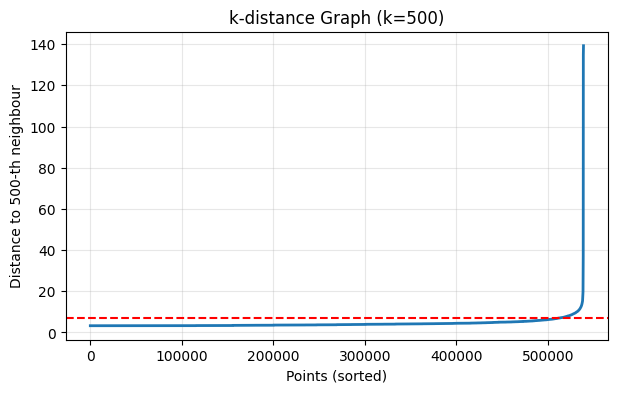


=== SELECTED DBSCAN PARAMETERS (DBI ONLY) ===
eps = 8.0
min_samples = 200.0
DBI = 0.5126
clusters = 6.0, noise = 0.00


Final noise percentage = 0.002



/tmp/ipykernel_3341800/1737337475.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged_clusters = pd.concat([merged_clusters] + dfs, ignore_index=True)


In [17]:
drought, grid_drought, param_drought, noise_drought = single_hazard_cluster('drought','SPI_12',0.3,5,500,'_YES_F_')

In [24]:
param_drought.min_samples.unique()

array([200, 400, 500, 600, 800])

In [20]:
param_drought

,eps,min_samples,dbi,noise_pct,clusters
0,3.000000,200,0.775008,0.071179,59
1,3.000000,400,NaN,1.000000,0
2,3.000000,500,NaN,1.000000,0
3,3.000000,600,NaN,1.000000,0
4,3.000000,800,NaN,1.000000,0
5,4.000000,200,0.687839,0.022725,34
6,4.000000,400,0.722508,0.076292,33
7,4.000000,500,0.694388,0.122772,36
8,4.000000,600,0.713107,0.185574,31
9,4.000000,800,0.654523,0.413521,18


In [18]:
dbi_min = param_drought['dbi'].min()
dbi_max = param_drought['dbi'].max()
print("DBI range:", dbi_min, "-->", dbi_max)

DBI range: 0.5125840093247721 --> 0.785698571816908


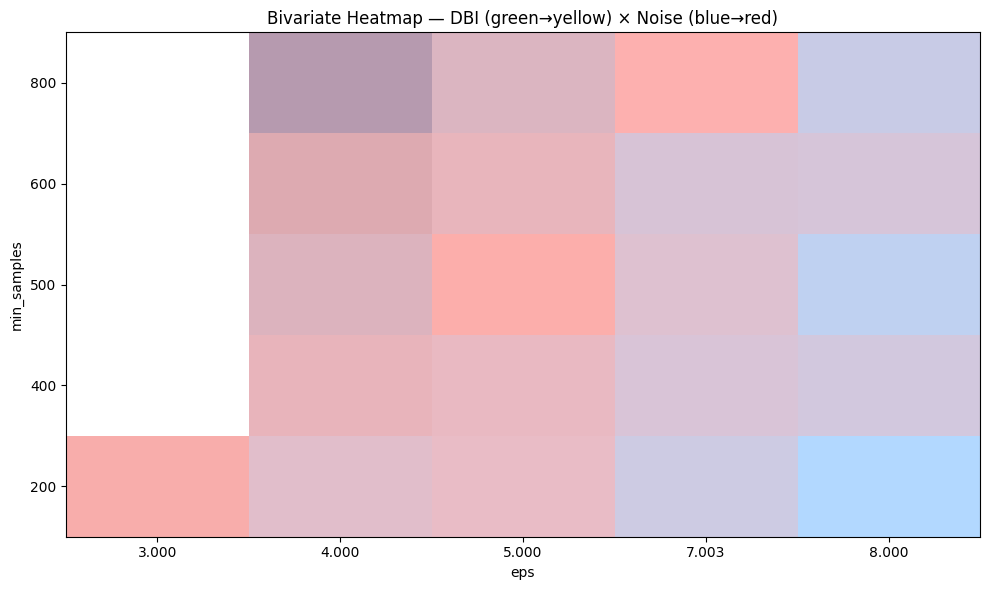

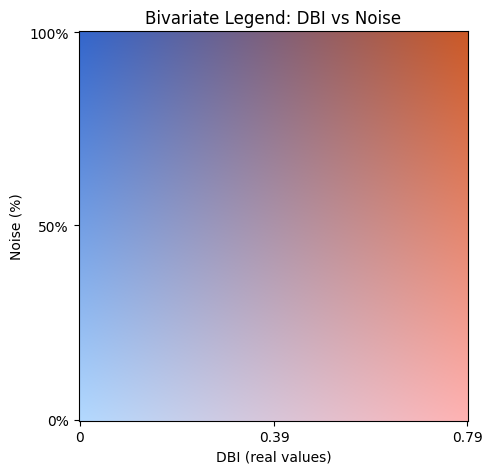

In [19]:
plot_bivariate_heatmap(param_drought)
plot_bivariate_legend_real_axes(dbi_max)